# Zomato Restaurant Data Analysis

## Project Objective

The objective of this project is to analyze the Zomato restaurant dataset to identify trends in restaurant types, cuisines, ratings, pricing, and online ordering. The insights generated can help businesses make better decisions and improve customer experience.

In [2]:
import pandas as pd
df = pd.read_csv("zomato.csv")

# Display the first five rows of the dataset
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [3]:
df.shape

(56252, 13)

In [4]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [5]:
df.describe()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


In [6]:
df.isnull().sum()

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


# Data Cleaning

In this section, the dataset is cleaned by removing duplicate records, handling missing values, removing unnecessary columns, and converting data into appropriate formats for analysis.


In [7]:
df.duplicated().sum()

np.int64(15703)

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(40549, 13)

In [10]:
df = df.drop(['address','phone'], axis=1)

In [11]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)'],
      dtype='object')

In [14]:
df['rate'] = df['rate'].astype(str)

df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = df['rate'].str.strip()

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [15]:
df['rate'].head()

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8


In [16]:
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].str.replace(",", "")
df["approx_cost(for two people)"] = pd.to_numeric(df["approx_cost(for two people)"], errors="coerce")

In [17]:
df["approx_cost(for two people)"].head()

,approx_cost(for two people)
0,800.0
1,800.0
2,800.0
3,300.0
4,600.0


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand patterns, trends, and relationships in the restaurant data using visualizations.

## Visualization 1: Top Restaurant Types

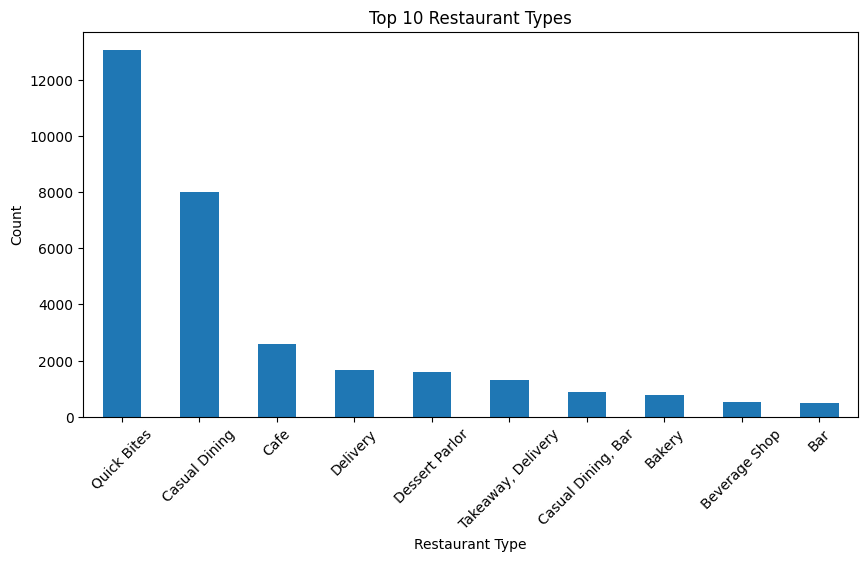

In [29]:
import matplotlib.pyplot as plt

top_restaurants = df['rest_type'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_restaurants.plot(kind='bar')
plt.title("Top 10 Restaurant Types")
plt.xlabel("Restaurant Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("restaurant_types.png", dpi=300, bbox_inches='tight')
plt.show()
plt.show()

## Business Insight

The majority of restaurants belong to a few popular restaurant types, indicating that customers prefer these categories. Businesses can focus on these popular restaurant types for marketing and partnerships.

## Visualization 2: Top 10 Cuisines

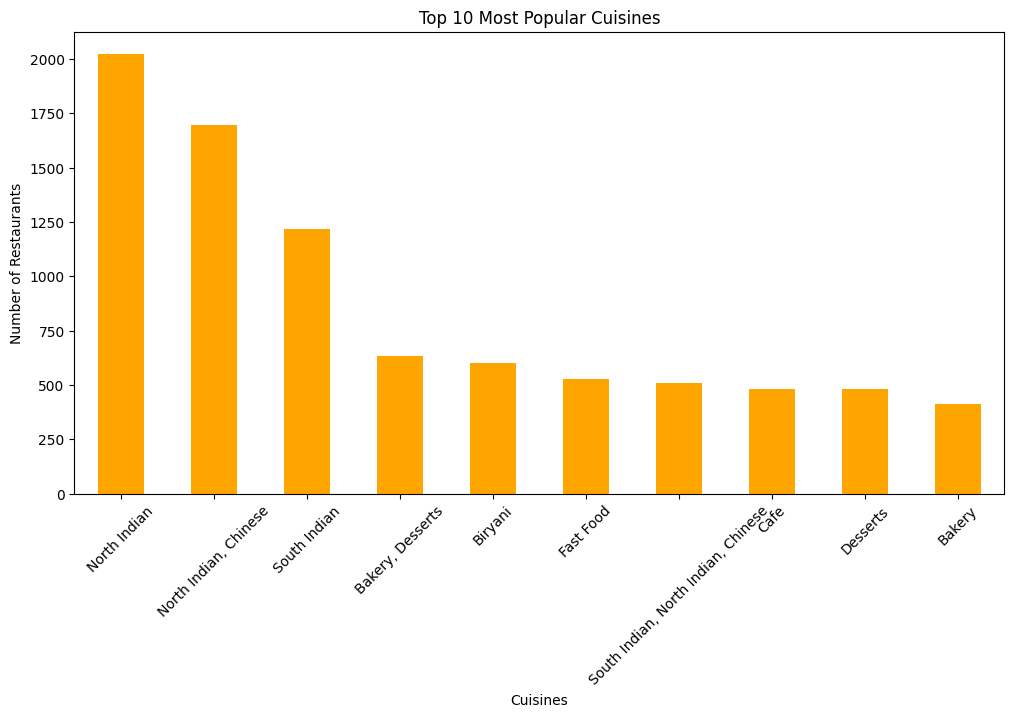

In [30]:
top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_cuisines.plot(kind='bar', color='orange')
plt.title("Top 10 Most Popular Cuisines")
plt.xlabel('Cuisines')
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.savefig("cuisines.png", dpi=300, bbox_inches='tight')
plt.show()
plt.show()

## Business Insight

North Indian and Chinese cuisines dominate the restaurant market. Restaurants serving these cuisines have a larger customer base and offer strong partnership opportunities.


## Visualization 3: Online Order Availability

In [33]:
print(df['online_order'].unique())

['Yes' 'No' " ('Rated 4.0'" ...
 ' ""RATED\\n  Truly what a wonderful place. From the walk through the green route to the actual place'
 ' dirty tables etc... is really a turn off...\\n\\nFood - 7/10\\n\\nVeg Nachos - Lacks the punch... wish the salsa tasted better... nd also wud be grt if u cud introduce an option without gluocumole (not really a fan of it)\\n\\nVeg Sheek Kabab - Tasted Grt'
 " 'RATED\\n  Beer cafe "]


In [34]:
df['online_order'] = df['online_order'].astype(str).str.strip()

In [36]:
online_order = df[df['online_order'].isin(['Yes', 'No'])]['online_order'].value_counts()

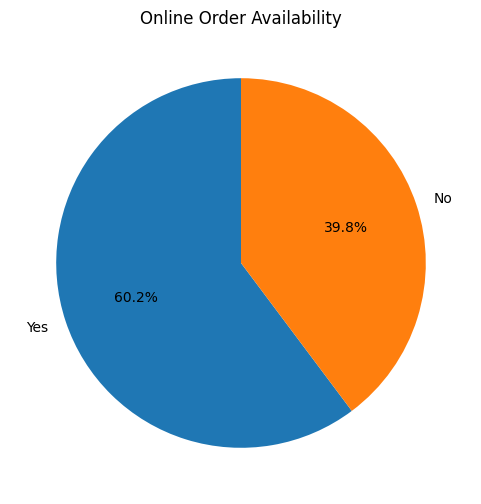

In [39]:
plt.figure(figsize=(6,6))
plt.pie(online_order, labels=online_order.index, autopct='%1.1f%%', startangle=90)
plt.title("Online Order Availability")
plt.savefig("online_order.png", dpi=300, bbox_inches='tight')
plt.show()
plt.show()

## Business Insight

A large percentage of restaurants provide online ordering, highlighting the increasing importance of food delivery services and digital ordering platforms.

## Visualization 4: Restaurant Rating Distribution

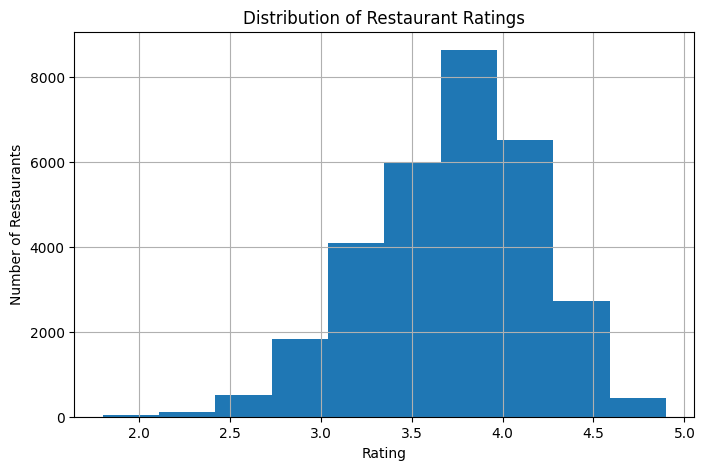

In [32]:
plt.figure(figsize=(8,5))

df['rate'].hist(bins=10)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.savefig("ratings.png", dpi=300, bbox_inches='tight')
plt.show()
plt.show()

## Business Insight

Most restaurants have ratings between 3.5 and 4.5, indicating that customers are generally satisfied with the quality of restaurants in the dataset.

## Visualization 5: Top 10 Restaurant Locations

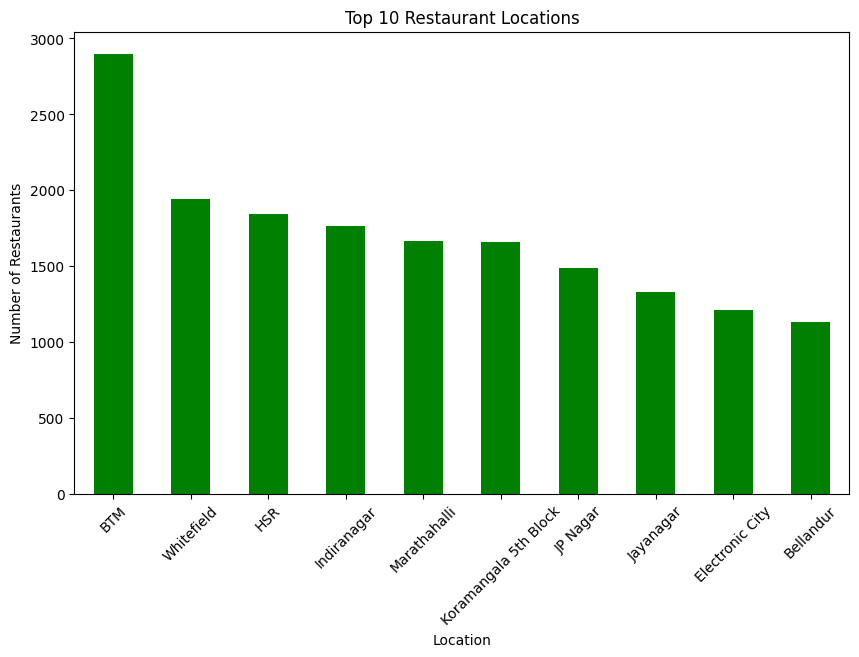

In [26]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_locations.plot(kind='bar', color='green')

plt.title("Top 10 Restaurant Locations")
plt.xlabel("Location")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)

plt.show()

## Business Insight

Some locations have a much higher concentration of restaurants, indicating areas with strong customer demand and high business activity.

## Visualization 6: Price vs Rating

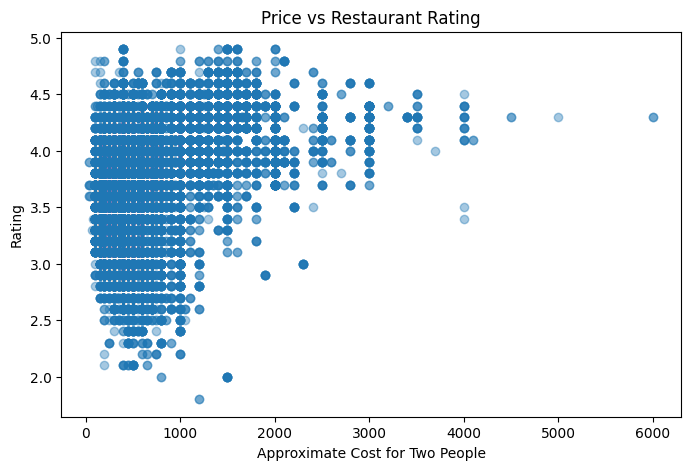

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['approx_cost(for two people)'],
    df['rate'],
    alpha=0.4
)

plt.title("Price vs Restaurant Rating")
plt.xlabel("Approximate Cost for Two People")
plt.ylabel("Rating")

plt.show()

## Business Insight

Higher-priced restaurants do not always receive higher ratings. Customer satisfaction depends on factors beyond price, such as food quality and service.


# Final Clean Dataset

In [28]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Buffet


# Business Recommendations

1. Focus on expanding restaurants in high-demand locations.

2. Promote popular cuisines such as North Indian and Chinese.

3. Encourage more restaurants to provide online ordering services.

4. Improve customer satisfaction to maintain ratings above 4.0.

5. Offer affordable pricing while maintaining food quality.

# Conclusion

This project analyzed the Zomato restaurant dataset using Python, Pandas, and Matplotlib. The analysis identified popular cuisines, restaurant types, customer ratings, pricing patterns, and online ordering trends. These insights can help restaurant owners and food delivery platforms make better business decisions.

# Final Observations

1. North Indian and Chinese cuisines are the most popular.
2. Most restaurant ratings fall between 3.5 and 4.5.
3. Online ordering is offered by a large number of restaurants.
4. Some locations have significantly more restaurants than others.
5. Restaurant ratings are not determined by price alone.